NameError: name 'plotted' is not defined

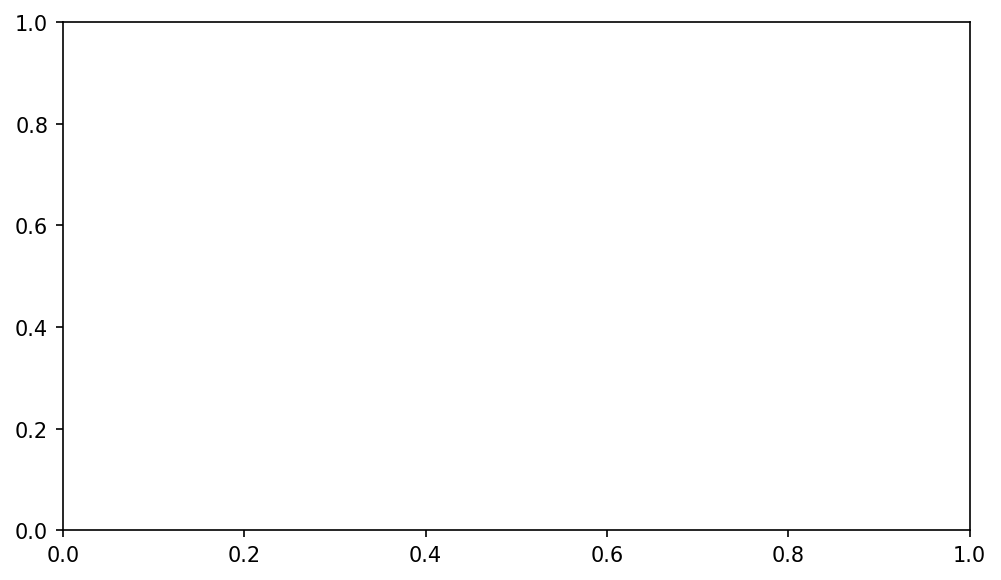

In [40]:
def plot_multi_step_series(
    series: list[tuple[str, str]],
    title: str = "Title",
    x_label: str = "X Axis",
    y_label: str = "Y Axis",
    baselines=None,
    ylim: tuple | None = (0, 1),
    savepath: str | None = None,
    improvement_only: bool = True,
    improvement_strict: bool = True,
    extend_to_global_end: bool = True,
    # --- NEW legend controls ---
    legend_where: str = "outside_top",   # "outside_top" | "outside_right" | "inside_best"
    legend_ncol_models: int = 3,
    legend_ncol_baselines: int = 3,
    legend_fontsize: int = 10,
):
    ...
    # --- draw ---
    # widen a bit to make room for outside legends
    figsize = (7.8, 4.4) if legend_where in ("outside_top", "outside_right") else (6.2, 4.0)
    plt.figure(figsize=figsize, dpi=150)
    ax = plt.gca()

    model_lines = []
    for label, x, y in plotted:
        ln, = ax.plot(x, y, "-o", linewidth=3.5, markersize=6, label=label)
        model_lines.append(ln)

    # --- baselines (collect handles for a separate legend row) ---
    baseline_handles = []
    if baselines:
        for i, b in enumerate(baselines):
            if isinstance(b, tuple):
                yb, blabel, color = (b + (None,))[:3]
                color = color or ("red" if i == 0 else "green")
            else:
                yb, blabel, color = float(b), None, ("red" if i == 0 else "green")
            ax.axhline(yb, linestyle="--", linewidth=2, color=color)
            if blabel:
                baseline_handles.append(
                    plt.Line2D([0], [0], linestyle="--", color=color, linewidth=2, label=blabel)
                )

    ...
    # --- legends (outside, non-overlapping) ---
    if legend_where == "outside_top":
        # row 1: models (closest to axes)
        lg1 = ax.legend(handles=model_lines,
                        labels=[h.get_label() for h in model_lines],
                        loc="lower center", bbox_to_anchor=(0.5, 1.02),
                        ncol=legend_ncol_models, frameon=False, fontsize=legend_fontsize)
        ax.add_artist(lg1)
        # row 2: baselines (above models)
        if baseline_handles:
            ax.legend(handles=baseline_handles,
                      labels=[h.get_label() for h in baseline_handles],
                      loc="lower center", bbox_to_anchor=(0.5, 1.16),
                      ncol=min(legend_ncol_baselines, len(baseline_handles)),
                      frameon=False, fontsize=legend_fontsize)
        plt.subplots_adjust(top=0.82)  # give the two rows breathing room

    elif legend_where == "outside_right":
        lg1 = ax.legend(handles=model_lines,
                        labels=[h.get_label() for h in model_lines],
                        loc="upper left", bbox_to_anchor=(1.02, 1),
                        frameon=False, fontsize=legend_fontsize, borderaxespad=0.0)
        if baseline_handles:
            ax.legend(handles=baseline_handles,
                      labels=[h.get_label() for h in baseline_handles],
                      loc="upper left", bbox_to_anchor=(1.02, 0.55),
                      frameon=False, fontsize=legend_fontsize, borderaxespad=0.0)
        plt.subplots_adjust(right=0.78)  # make space on the right

    else:  # "inside_best" (fallback)
        ax.legend(frameon=False, loc="best", fontsize=legend_fontsize)

dataGPT = """
0   0
1   0.2666666667
2   0.5666666667
3   0.6666666667
4   0.4
5   0.2333333333
6   0.5
7   0.5666666667
8   0.6
9   0.4666666667
10  0.7333333333
"""

dataMISTRAL = """
0	0
1	0.4666666667
2	0.3
3	0.4666666667
4	0.2666666667
5	0.27
6	0.2333333333
"""

dataCLAUDE = """
0	0
1	0.3666666667
2	0.5333333333
3	0.1333333333
4	0.2666666667
5	0.325
6	0.3
7	0.2
8	0.2
9	0.3666666667
10	0.4333333333
"""
dataNoDiscovery = """
Evolution	WinRate(30)
0	0
0	0
""" 
plot_multi_step_series(
    [
        ("Mistral", dataMISTRAL),
        ("Claude", dataCLAUDE),
        ("GPT-4o", dataGPT),
        ("No Discovery", dataNoDiscovery)
    ],
    title="HexMachina Win Rate vs. Evolutions",
    x_label="Evolution Number",
    y_label="Win Rate",
    baselines=[(0.02, "Random", "green"),
               (0.164, "LLM Player", "red"),
               (0.47, "Alpha Beta", "orange")],
    ylim=(0, 1.1),
    improvement_only=True,
    improvement_strict=True,
    legend_where="outside_top",          # ← two tidy rows above the plot
    legend_ncol_models=3,
    legend_ncol_baselines=3,
    legend_fontsize=10
)



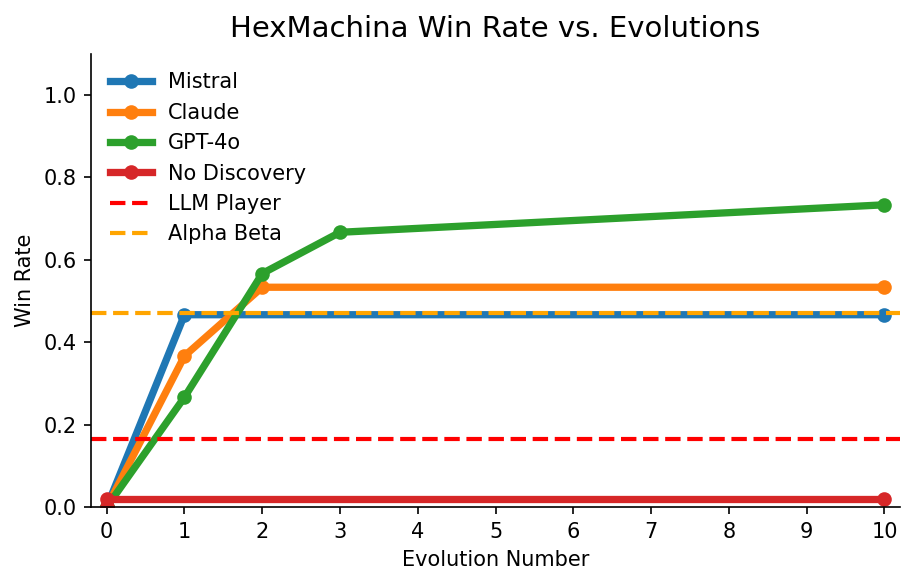

In [44]:
import re
import matplotlib.pyplot as plt
import numpy as np

def _parse_table(text_block: str):
    steps, vals = [], []
    lines = [ln.strip() for ln in text_block.strip().splitlines() if ln.strip()]
    start_idx = 1 if lines and not re.match(r"^-?\d+(\.\d+)?", lines[0].split()[0]) else 0
    for ln in lines[start_idx:]:
        parts = re.split(r"\s+", ln)
        if len(parts) < 2:
            continue
        steps.append(int(float(parts[0])))
        vals.append(float(parts[1]))
    return np.asarray(steps, float), np.asarray(vals, float)

def _improvement_filter(x: np.ndarray, y: np.ndarray, strict: bool = True):
    if y.size == 0:
        return x, y
    keep_x = [x[0]]
    keep_y = [y[0]]
    best = y[0]
    for xi, yi in zip(x[1:], y[1:]):
        improved = (yi > best) if strict else (yi >= best)
        if improved:
            keep_x.append(xi); keep_y.append(yi); best = yi
    return np.asarray(keep_x, float), np.asarray(keep_y, float)

def plot_multi_step_series(
    series: list[tuple[str, str]],     # [(label, text_block), ...]
    title: str = "Title",
    x_label: str = "X Axis",
    y_label: str = "Y Axis",
    baselines=None,                    # numbers or (value,label,color)
    ylim: tuple | None = (0, 1),
    savepath: str | None = None,       # "figure.png" (also writes PDF)
    improvement_only: bool = True,
    improvement_strict: bool = True,
    extend_to_global_end: bool = True  # append a horizontal tail to the final x
):
    # Parse and bounds
    parsed_raw, all_x = [], []
    for label, txt in series:
        xr, yr = _parse_table(txt)
        parsed_raw.append((label, xr, yr))
        if xr.size: all_x.append(xr)
    if not all_x:
        raise ValueError("No data provided.")
    x_min, x_max = min(x.min() for x in all_x), max(x.max() for x in all_x)

    # Prepare plotted series
    plotted = []
    for label, xr, yr in parsed_raw:
        xk, yk = _improvement_filter(xr, yr, strict=improvement_strict) if improvement_only else (xr, yr)
        # add a horizontal tail only at the very end
        if extend_to_global_end and xk.size and xk[-1] < x_max:
            xk = np.append(xk, x_max)
            yk = np.append(yk, yk[-1])
        plotted.append((label, xk, yk))

    # Draw (regular line style, no steps)
    plt.figure(figsize=(6.2, 4.0), dpi=150)
    ax = plt.gca()
    for label, x, y in plotted:
        ax.plot(x, y, "-o", linewidth=3.5, markersize=6, label=label)  # <-- no drawstyle="steps-post"

    # Baselines
    legend_items = []
    if baselines:
        for i, b in enumerate(baselines):
            if isinstance(b, tuple):
                yb, blabel, color = (b + (None,))[:3]
                color = color or ("red" if i == 0 else "green")
            else:
                yb, blabel, color = float(b), None, ("red" if i == 0 else "green")
            ax.axhline(yb, linestyle="--", linewidth=2, color=color)
            if blabel: legend_items.append((yb, blabel, color))

    ax.set_xlabel(x_label); ax.set_ylabel(y_label)
    ax.set_xticks(np.arange(int(x_min), int(x_max) + 1))
    ax.set_xlim(x_min - 0.2, x_max + 0.2)
    if ylim: ax.set_ylim(*ylim)
    ax.set_title(title, fontsize=14, pad=8)
    ax.spines[["top","right"]].set_visible(False)

    # legend
    handles, labels = ax.get_legend_handles_labels()
    if legend_items:
        baseline_handles = [plt.Line2D([0],[0], linestyle="--", color=c, linewidth=2, label=lbl)
                            for _, lbl, c in legend_items]
        handles += baseline_handles
    if handles: ax.legend(handles=handles, frameon=False, loc="best")

    plt.tight_layout()
    if savepath:
        import os
        stem,_ = os.path.splitext(savepath)
        plt.savefig(f"{stem}.png", bbox_inches="tight")
        plt.savefig(f"{stem}.pdf", bbox_inches="tight")
    plt.show()


dataGPT = """
0   0
1   0.2666666667
2   0.5666666667
3   0.6666666667
4   0.4
5   0.2333333333
6   0.5
7   0.5666666667
8   0.6
9   0.4666666667
10  0.7333333333
"""

dataMISTRAL = """
0	0
1	0.4666666667
2	0.3
3	0.4666666667
4	0.2666666667
5	0.27
6	0.2333333333
"""

dataCLAUDE = """
0	0
1	0.3666666667
2	0.5333333333
3	0.1333333333
4	0.2666666667
5	0.325
6	0.3
7	0.2
8	0.2
9	0.3666666667
10	0.4333333333
"""
dataNoDiscovery = """
Evolution	WinRate(30)
0	0
0	0.02
"""

plot_multi_step_series(
    [
        ("Mistral", dataMISTRAL),
        ("Claude", dataCLAUDE),
        ("GPT-4o", dataGPT),
        ("No Discovery", dataNoDiscovery)
    ],
    title="HexMachina Win Rate vs. Evolutions",
    x_label="Evolution Number",
    y_label="Win Rate",
    baselines=[(0.164, "LLM Player", "red"), (0.47, "Alpha Beta", "orange")],
    ylim=(0, 1.1),
    improvement_only=True,       # only show improvements for each line
    improvement_strict=True      # set False to keep ties as improvements
)


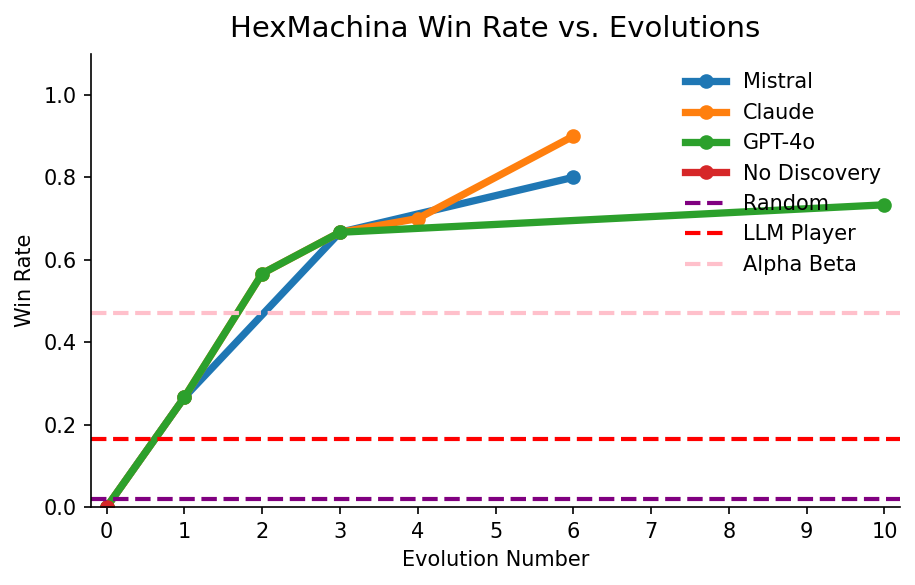

In [37]:
import re
import matplotlib.pyplot as plt
import numpy as np

def _parse_table(text_block: str):
    """Parse 'step value' pairs from a pasted table (with or without a header)."""
    steps, vals = [], []
    lines = [ln.strip() for ln in text_block.strip().splitlines() if ln.strip()]
    start_idx = 1 if lines and not re.match(r"^-?\d+(\.\d+)?", lines[0].split()[0]) else 0
    for ln in lines[start_idx:]:
        parts = re.split(r"\s+", ln)
        if len(parts) < 2:
            continue
        steps.append(int(float(parts[0])))
        vals.append(float(parts[1]))
    return np.asarray(steps, float), np.asarray(vals, float)

def _improvement_filter(x: np.ndarray, y: np.ndarray, strict: bool = True):
    """Keep first point, then only points that improve the running best."""
    if y.size == 0:
        return x, y
    keep_x = [x[0]]
    keep_y = [y[0]]
    best = y[0]
    for xi, yi in zip(x[1:], y[1:]):
        improved = (yi > best) if strict else (yi >= best)
        if improved:
            keep_x.append(xi)
            keep_y.append(yi)
            best = yi
    return np.asarray(keep_x, float), np.asarray(keep_y, float)

def plot_multi_step_series(
    series: list[tuple[str, str]],     # [(label, text_block), ...]
    title: str = "Title",
    x_label: str = "X Axis",
    y_label: str = "Y Axis",
    baselines=None,                    # e.g., [0.8, 1.0] or [(y, "name", "color")]
    ylim: tuple | None = (0, 1),
    savepath: str | None = None,       # "figure.png" (also writes PDF)
    improvement_only: bool = True,
    improvement_strict: bool = True,
):
    """
    Plot multiple 'step/value' series on one chart.
    - Each series is a (label, text_block) pair.
    - If improvement_only=True, only the improving points are shown/connected per series.
    - Baselines can be numbers or (value, label, color) tuples.
    """
    # Parse all series first
    parsed = []
    all_x_for_bounds = []
    for label, txt in series:
        x, y = _parse_table(txt)
        if improvement_only:
            x, y = _improvement_filter(x, y, strict=improvement_strict)
        parsed.append((label, x, y))
        if x.size:
            all_x_for_bounds.append(x)

    # Draw
    plt.figure(figsize=(6.2, 4.0), dpi=150)
    ax = plt.gca()

    # Plot each series (cycle default colors)
    for label, x, y in parsed:
        ax.plot(x, y, "-o", linewidth=3.5, markersize=6, label=label)

    # Baselines
    legend_items = []
    if baselines:
        for i, b in enumerate(baselines):
            if isinstance(b, tuple):
                yb, blabel, color = (b + (None,))[:3]
                color = color or ("red" if i == 0 else "green")
            else:
                yb, blabel, color = float(b), None, ("red" if i == 0 else "green")
            ax.axhline(yb, linestyle="--", linewidth=2, color=color)
            if blabel:
                legend_items.append((yb, blabel, color))

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    # X ticks: use all provided steps if available; else fall back to union of bounds
    if all_x_for_bounds:
        x_min = min(x.min() for x in all_x_for_bounds)
        x_max = max(x.max() for x in all_x_for_bounds)
        ax.set_xticks(np.arange(int(x_min), int(x_max) + 1))
        ax.set_xlim(x_min - 0.2, x_max + 0.2)

    if ylim:
        ax.set_ylim(*ylim)

    ax.set_title(title, fontsize=14, pad=8)
    ax.spines[["top", "right"]].set_visible(False)

    # Legend (model lines + any named baselines)
    handles, labels = ax.get_legend_handles_labels()
    if legend_items:
        baseline_handles = [plt.Line2D([0], [0], linestyle="--", color=c, linewidth=2, label=lbl)
                            for _, lbl, c in legend_items]
        handles += baseline_handles
    if handles:
        ax.legend(handles=handles, frameon=False, loc="best")

    plt.tight_layout()

    if savepath:
        import os
        stem, _ = os.path.splitext(savepath)
        plt.savefig(f"{stem}.png", bbox_inches="tight")
        plt.savefig(f"{stem}.pdf", bbox_inches="tight")

    plt.show()

dataGPT = """
0   0
1   0.2666666667
2   0.5666666667
3   0.6666666667
4   0.4
5   0.2333333333
6   0.5
7   0.5666666667
8   0.6
9   0.4666666667
10  0.7333333333
"""

dataMISTRAL = """
0   0
1   0.2666666667
2   0.2
3   0.6666666667
4   0.4
5   0.2333333333
6   0.8
7   0.5666666667
8   0.6
9   0.4666666667
10  0.8
"""

dataCLAUDE = """
0   0
1   0.2666666667
2   0.5666666667
3   0.6666666667
4   0.7
5   0.2333333333
6   0.9
7   0.5666666667
8   0.6
9   0.9
10  0.9
"""

dataNoDiscovery = """
Evolution	WinRate(30)
0	0
0	0
"""

plot_multi_step_series(
    [
        ("Mistral", dataMISTRAL),
        ("Claude", dataCLAUDE),
        ("GPT-4o", dataGPT),
        ("No Discovery", dataNoDiscovery)
    ],
    title="HexMachina Win Rate vs. Evolutions",
    x_label="Evolution Number",
    y_label="Win Rate",
    baselines=[(0.02, "Random", "purple"), (0.164, "LLM Player", "red"), (0.47, "Alpha Beta", "pink")],
    ylim=(0, 1.1),
    improvement_only=True,       # only show improvements for each line
    improvement_strict=True      # set False to keep ties as improvements
)


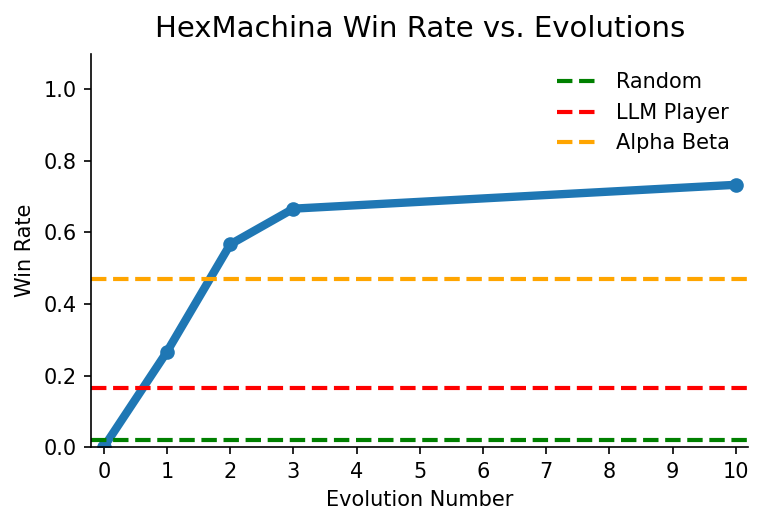

In [38]:
import re
import matplotlib.pyplot as plt
import numpy as np

def plot_step_series(
    text_block: str,
    title: str = "Title",
    x_label: str = "X Axis",
    y_label: str = "Y Axis",
    baselines=None,
    ylim: tuple | None = (0, 1),
    savepath: str | None = None,
    improvement_only: bool = True,      # ← NEW: show only improving points on the blue curve
    improvement_strict: bool = True     # ← NEW: if False, >= is considered an improvement
):
    """
    Parse a 'Step / Value' table and draw a paper-style line plot.

    improvement_only:
      - If True, the blue curve keeps only the first sample and points that
        strictly improve the running best (or >= if improvement_strict=False).

    baselines:
      - numbers [0.8, 1.0] or tuples [(y, label, color), ...]
    """
    # ---- parse the pasted table ----
    steps, vals = [], []
    lines = [ln.strip() for ln in text_block.strip().splitlines() if ln.strip()]
    # treat first line as header if its first token isn't numeric
    start_idx = 1 if lines and not re.match(r"^-?\d+(\.\d+)?", lines[0].split()[0]) else 0

    for ln in lines[start_idx:]:
        parts = re.split(r"\s+", ln)
        if len(parts) < 2:
            continue
        steps.append(int(float(parts[0])))
        vals.append(float(parts[1]))

    x = np.array(steps, dtype=float)
    y = np.array(vals, dtype=float)

    # ---- keep only improvements (first point always kept) ----
    if improvement_only and len(y) > 0:
        keep_x = [x[0]]
        keep_y = [y[0]]
        best = y[0]
        for xi, yi in zip(x[1:], y[1:]):
            improved = (yi > best) if improvement_strict else (yi >= best)
            if improved:
                keep_x.append(xi)
                keep_y.append(yi)
                best = yi
        x_plot = np.array(keep_x, dtype=float)
        y_plot = np.array(keep_y, dtype=float)
    else:
        x_plot, y_plot = x, y

    # ---- draw ----
    plt.figure(figsize=(5.2, 3.6), dpi=150)
    ax = plt.gca()

    # main series: only improvements are shown/connected
    ax.plot(x_plot, y_plot, "-o", linewidth=4, markersize=6, color="#1f77b4")

    # baselines (optional)
    legend_items = []
    if baselines:
        for i, b in enumerate(baselines):
            if isinstance(b, tuple):
                yb, label, color = (b + (None,))[:3]
                color = color or ("red" if i == 0 else "green")
            else:
                yb, label, color = float(b), None, ("red" if i == 0 else "green")
            ax.axhline(yb, linestyle="--", linewidth=2, color=color)
            if label:
                legend_items.append((yb, label, color))

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_xticks(x.astype(int))
    if ylim:
        ax.set_ylim(*ylim)
    # widen bounds a touch using full x range so baselines/axes look right
    if len(x) > 0:
        ax.set_xlim(x.min() - 0.2, x.max() + 0.2)

    ax.set_title(title, fontsize=14, pad=8)
    ax.spines[["top", "right"]].set_visible(False)

    if legend_items:
        handles = [plt.Line2D([0], [0], linestyle="--", color=c, linewidth=2, label=lbl)
                   for _, lbl, c in legend_items]
        ax.legend(handles=handles, frameon=False, loc="best")

    plt.tight_layout()

    if savepath:
        import os
        stem, _ = os.path.splitext(savepath)
        plt.savefig(f"{stem}.png", bbox_inches="tight")
        plt.savefig(f"{stem}.pdf", bbox_inches="tight")

    plt.show()


dataGPT = """
0   0
1   0.2666666667
2   0.5666666667
3   0.6666666667
4   0.4
5   0.2333333333
6   0.5
7   0.5666666667
8   0.6
9   0.4666666667
10  0.7333333333
"""

plot_step_series(
    dataGPT,  # your pasted table
    title="HexMachina Win Rate vs. Evolutions",
    x_label="Evolution Number",
    y_label="Win Rate",
    baselines=[(0.02, "Random", "green"), (0.164, "LLM Player", "red"), (0.47, "Alpha Beta", "orange")],
    ylim=(0, 1.1),
    improvement_only=True,      # only plot improving points
    improvement_strict=True     # change to False to keep equal ties too
)


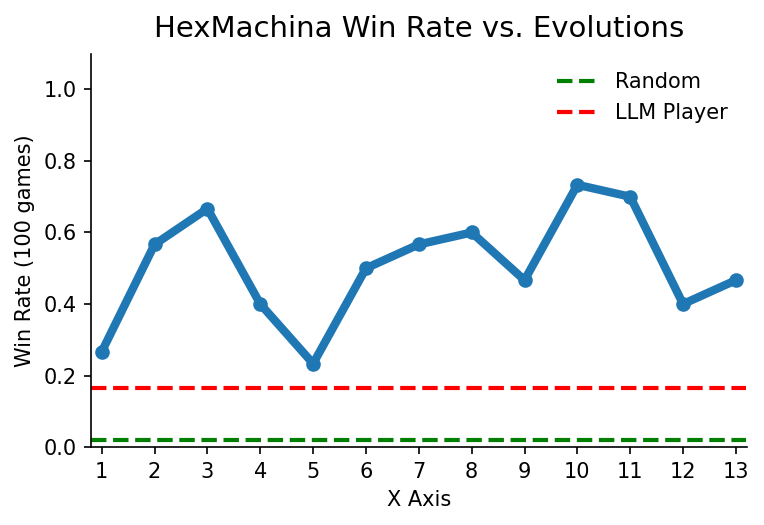

In [39]:
import re
import matplotlib.pyplot as plt
import numpy as np

def plot_step_series(
    text_block: str,
    title: str = "Title",
    x_label: str = "X Axis",
    y_label: str = "Y Axis",
    baselines=None,              
    ylim: tuple | None = (0, 1), # set None to auto
    savepath: str | None = None  # e.g., "figure.png" (also saves a PDF with same stem)
):
    """
    Parse a 'Step / WinRate(100)' table and plot a research-paper style line plot.
    - baselines can be:
        • a list of numbers [0.8, 1.0]
        • or a list of tuples: [(y, label, color), ...]
    """
    # ---- parse the pasted table ----
    steps, vals = [], []
    lines = [ln.strip() for ln in text_block.strip().splitlines() if ln.strip()]
    # skip header row (expects something like: "Step    WinRate(100)")
    for ln in lines[1:]:
        # split on tab or spaces
        parts = re.split(r"\s+", ln)
        if len(parts) < 2:
            continue
        steps.append(int(parts[0]))
        vals.append(float(parts[1]))

    x = np.array(steps, dtype=float)
    y = np.array(vals, dtype=float)

    # ---- draw ----
    plt.figure(figsize=(5.2, 3.6), dpi=150)
    ax = plt.gca()

    # main series (no error bars)
    ax.plot(x, y, "-o", linewidth=4, markersize=6, color="#1f77b4")

    # baselines
    legend_items = []
    if baselines:
        for i, b in enumerate(baselines):
            if isinstance(b, tuple):
                yb, label, color = (b + (None,))[:3]  # tolerate 2- or 3-tuples
                color = color or ("red" if i == 0 else "green")
            else:
                yb, label, color = float(b), None, ("red" if i == 0 else "green")
            ax.axhline(yb, linestyle="--", linewidth=2, color=color)
            if label:
                legend_items.append((yb, label, color))

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_xticks(x.astype(int))
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_xlim(x.min() - 0.2, x.max() + 0.2)
    ax.set_title(title, fontsize=14, pad=8)
    ax.spines[["top", "right"]].set_visible(False)

    # optional legend if you named baselines
    if legend_items:
        # create dummy handles just for labels
        handles = [plt.Line2D([0], [0], linestyle="--", color=c, linewidth=2, label=lbl)
                   for _, lbl, c in legend_items]
        ax.legend(handles=handles, frameon=False, loc="best")

    plt.tight_layout()

    if savepath:
        import os
        stem, _ = os.path.splitext(savepath)
        plt.savefig(f"{stem}.png", bbox_inches="tight")
        plt.savefig(f"{stem}.pdf", bbox_inches="tight")

    plt.show()


# -------- Example usage (paste your data here) --------
data = """
0	0
1	0.2666666667
2	0.5666666667
3	0.6666666667
4	0.4
5	0.2333333333
6	0.5
7	0.5666666667
8	0.6
9	0.4666666667
10	0.7333333333
11	0.7
12	0.40
13	0.4666666667
"""

# You can pass just numbers for baselines, or (value, label, color)
plot_step_series(
    data,
    title="HexMachina Win Rate vs. Evolutions",
    y_label="Win Rate (100 games)",
    baselines=[(0.02, "Random", "green"), (0.164, "LLM Player", "red")],
    ylim=(0, 1.1),
    savepath=None  # e.g., "winrate_curve.png"
)
